### **Quantium Virtual Internship - Retail Strategy and Analytics - Task 1**

## Objective

The objective of this analysis is to understand customer purchasing behaviour within the chips category and identify the customer segments that contribute most strongly to sales performance.

The analysis includes:
- data quality checks and cleaning
- feature engineering
- customer segmentation analysis
- purchasing behaviour analysis
- brand and pack size insights
- strategic recommendations for the category review


In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install openpyxl


In [118]:
try:

  customer_data=pd.read_csv('/content/QVI_purchase_behaviour.csv')
  transactions_data=pd.read_excel('/content/QVI_transaction_data.xlsx')
  print(f'Successfully loaded the data {customer_data.shape} ')
  print(f'Successfully loaded the data {transactions_data.shape} ')
except Exception as e:
  print(f'Error loading the data {e}')

Successfully loaded the data (72637, 3) 
Successfully loaded the data (264836, 8) 


##**Checking the Data Quality**

In [119]:
transactions_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [120]:
customer_data.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [121]:
transactions_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [122]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


###Missing Values
Both datasets contain no missing values.  
The transaction date column is stored as an integer, so it needs to be converted into a proper date format before time-based analysis.

In [123]:
transactions_data.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836.000000,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,43464.036260,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
std,105.389282,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226
min,43282.000000,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,43646.000000,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


### **Data Cleaning and Feature Engineering**




In [124]:
# Convert 'DATE' to datetime objects
transactions_data['DATE'] = pd.to_datetime(
    transactions_data['DATE'],
    unit='D',
    origin='1899-12-30'
)


In [125]:
# Confirming date format conversion
transactions_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264836 non-null  datetime64[ns]
 1   STORE_NBR       264836 non-null  int64         
 2   LYLTY_CARD_NBR  264836 non-null  int64         
 3   TXN_ID          264836 non-null  int64         
 4   PROD_NBR        264836 non-null  int64         
 5   PROD_NAME       264836 non-null  object        
 6   PROD_QTY        264836 non-null  int64         
 7   TOT_SALES       264836 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 16.2+ MB


In [126]:
transactions_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


The transaction date was converted from Excel serial format into a readable date format.  
This allows analysis of sales trends over time, including monthly and seasonal purchasing behaviour.

###Outlier Detection
Initial summary statistics identified an unusually high purchase quantity of 200 units, which require further investigation as a potential outlier.

In [127]:
transactions_data[transactions_data['PROD_QTY'] == 200]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [128]:
transactions_data['PROD_QTY'].value_counts()

,count
PROD_QTY,
2,236039
1,27518
5,450
3,430
4,397
200,2


In [129]:
# Remove customer who purchased 200 packets (2 rows with same LYLTY_CARD_NBR)
transactions_data = transactions_data[
    transactions_data['LYLTY_CARD_NBR'] != 226000]

In [130]:
# Again checking if outlier has been removed
transactions_data['PROD_QTY'].value_counts()

,count
PROD_QTY,
2,236039
1,27518
5,450
3,430
4,397


Most transactions involved between 1 and 5 chip packets, with 2-packet purchases being the most common purchasing behaviour.  
Two transactions showed 200 packets purchased by the same customer, which is not representative of normal retail shopping behaviour.  
This customer was removed from the analysis to avoid distorting customer behaviour metrics.

In [131]:
transactions_data['PACK_SIZE']=transactions_data['PROD_NAME'].str.extract(r'(\d+)').astype(int)

In [132]:
transactions_data[['PROD_NAME','PACK_SIZE']].head(10)

,PROD_NAME,PACK_SIZE
0,Natural Chip Compny SeaSalt175g,175
1,CCs Nacho Cheese 175g,175
2,Smiths Crinkle Cut Chips Chicken 170g,170
3,Smiths Chip Thinly S/Cream&Onion 175g,175
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,150
5,Old El Paso Salsa Dip Tomato Mild 300g,300
6,Smiths Crinkle Chips Salt & Vinegar 330g,330
7,Grain Waves Sweet Chilli 210g,210
8,Doritos Corn Chip Mexican Jalapeno 150g,150
9,Grain Waves Sour Cream&Chives 210G,210


###**Feature Engineering**

Additional product-level features were derived from the product name field to support customer purchasing analysis.  
Pack size was extracted from product descriptions to analyse customer preferences across different packet sizes.

In [133]:
transactions_data['PACK_SIZE'].describe()

,PACK_SIZE
count,264834.000000
mean,182.425512
std,64.325148
min,70.000000
25%,150.000000
50%,170.000000
75%,175.000000
max,380.000000


In [134]:
transactions_data['PACK_SIZE'].value_counts().sort_index()

,count
PACK_SIZE,
70,1507
90,3008
110,22387
125,1454
134,25102
135,3257
150,43131
160,2970
165,15297


Pack sizes were successfully extracted from product names to support purchasing behaviour analysis.  

The most frequently purchased pack sizes were 175g and 150g, indicating strong customer preference for medium-sized chip packets.  
Pack sizes ranged from 70g to 380g, with an average pack size of approximately 182g.

In [135]:
transactions_data['BRAND'] = transactions_data['PROD_NAME'].str.split().str[0]

In [136]:
transactions_data['BRAND'].head(15)

,BRAND
0,Natural
1,CCs
2,Smiths
3,Smiths
4,Kettle
5,Old
6,Smiths
7,Grain
8,Doritos
9,Grain


In [137]:
transactions_data['BRAND'].value_counts().sort_values(ascending=True)

,count
BRAND,
French,1418
NCC,1419
Sunbites,1432
GrnWves,1468
Burger,1564
Snbts,1576
Cheetos,2927
Smith,2963
Infzns,3144


In [138]:
transactions_data['BRAND'] = transactions_data['BRAND'].replace({
    'Dorito': 'Doritos',
    'Smith': 'Smiths',
    'Red': 'RRD',
    'WW': 'Woolworths',
    'Infzns': 'Infuzions',
    'Snbts': 'Sunbites',
    'GrnWves': 'Grain Waves',
    'Grain':'Grain Waves',
    'NCC':'Natural'
})

In [139]:
transactions_data['BRAND'].value_counts().sort_values(ascending=True)

,count
BRAND,
French,1418
Burger,1564
Cheetos,2927
Sunbites,3008
CCs,4551
Cheezels,4603
Tyrrells,6442
Natural,7469
Grain Waves,7740


Brand names were also extracted and standardised to support brand-level customer analysis.

In [140]:
merged_data=pd.merge(transactions_data,
                    customer_data,
                    on='LYLTY_CARD_NBR',
                    how='left')

In [141]:
merged_data.head(10)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150,Kettle,MIDAGE SINGLES/COUPLES,Budget
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1,300,Old,MIDAGE SINGLES/COUPLES,Budget
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330,Smiths,MIDAGE SINGLES/COUPLES,Budget
7,2019-05-16,4,4196,3539,24,Grain Waves Sweet Chilli 210g,1,3.6,210,Grain Waves,MIDAGE SINGLES/COUPLES,Budget
8,2018-08-20,5,5026,4525,42,Doritos Corn Chip Mexican Jalapeno 150g,1,3.9,150,Doritos,MIDAGE SINGLES/COUPLES,Budget
9,2018-08-18,7,7150,6900,52,Grain Waves Sour Cream&Chives 210G,2,7.2,210,Grain Waves,MIDAGE SINGLES/COUPLES,Budget


In [142]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264834 non-null  datetime64[ns]
 1   STORE_NBR         264834 non-null  int64         
 2   LYLTY_CARD_NBR    264834 non-null  int64         
 3   TXN_ID            264834 non-null  int64         
 4   PROD_NBR          264834 non-null  int64         
 5   PROD_NAME         264834 non-null  object        
 6   PROD_QTY          264834 non-null  int64         
 7   TOT_SALES         264834 non-null  float64       
 8   PACK_SIZE         264834 non-null  int64         
 9   BRAND             264834 non-null  object        
 10  LIFESTAGE         264834 non-null  object        
 11  PREMIUM_CUSTOMER  264834 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(6), object(4)
memory usage: 24.2+ MB


In [143]:
merged_data[merged_data['LIFESTAGE'].isna()].shape

(0, 12)

## Merging Transaction and Customer Data

Transaction data was merged with customer segmentation data using the loyalty card number as the common key.  

This combined dataset allows analysis of purchasing behaviour across different customer lifestage and premium customer segments.

In [144]:
segment_sales = merged_data.groupby(
    ['LIFESTAGE', 'PREMIUM_CUSTOMER']
)['TOT_SALES'].sum().sort_values(ascending=False)

segment_sales

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              168363.25
YOUNG SINGLES/COUPLES   Mainstream          157621.60
RETIREES                Mainstream          155677.05
YOUNG FAMILIES          Budget              139345.85
OLDER SINGLES/COUPLES   Budget              136769.80
                        Mainstream          133393.80
                        Premium             132263.15
RETIREES                Budget              113147.80
OLDER FAMILIES          Mainstream          103445.55
RETIREES                Premium              97646.05
YOUNG FAMILIES          Mainstream           92788.75
MIDAGE SINGLES/COUPLES  Mainstream           90803.85
YOUNG FAMILIES          Premium              84025.50
OLDER FAMILIES          Premium              80658.40
YOUNG SINGLES/COUPLES   Budget               61141.60
MIDAGE SINGLES/COUPLES  Premium              58432.65
YOUNG SINGLES/COUPLES   Premium              41642.10
MIDAGE SINGLES/COUPLES  Budget               35514.80
NEW FAMILIES            Budget               21928.45
                        Mainstream           17013.90
                        Premium              11491.10
Name: TOT_SALES, dtype: float64

In [145]:
segment_customers = merged_data.groupby(
    ['LIFESTAGE', 'PREMIUM_CUSTOMER']
)['LYLTY_CARD_NBR'].nunique().sort_values(ascending=False)

segment_customers

LIFESTAGE               PREMIUM_CUSTOMER
YOUNG SINGLES/COUPLES   Mainstream          8088
RETIREES                Mainstream          6479
OLDER SINGLES/COUPLES   Mainstream          4930
                        Budget              4929
                        Premium             4750
OLDER FAMILIES          Budget              4675
RETIREES                Budget              4454
YOUNG FAMILIES          Budget              4017
RETIREES                Premium             3872
YOUNG SINGLES/COUPLES   Budget              3779
MIDAGE SINGLES/COUPLES  Mainstream          3340
OLDER FAMILIES          Mainstream          2831
YOUNG FAMILIES          Mainstream          2728
YOUNG SINGLES/COUPLES   Premium             2574
YOUNG FAMILIES          Premium             2433
MIDAGE SINGLES/COUPLES  Premium             2431
OLDER FAMILIES          Premium             2273
MIDAGE SINGLES/COUPLES  Budget              1504
NEW FAMILIES            Budget              1112
                        Mainstream           849
                        Premium              588
Name: LYLTY_CARD_NBR, dtype: int64

In [146]:
segment_metrics = merged_data.groupby(
    ['LIFESTAGE', 'PREMIUM_CUSTOMER']
).agg({
    'TOT_SALES': 'sum',
    'LYLTY_CARD_NBR': 'nunique',
    'TXN_ID': 'count'
})

In [147]:
segment_metrics['TXN_PER_CUSTOMER'] = (
    segment_metrics['TXN_ID'] /
    segment_metrics['LYLTY_CARD_NBR']
)

In [148]:
segment_metrics.sort_values(
    by='TXN_PER_CUSTOMER',
    ascending=False
)

TOT_SALES  LYLTY_CARD_NBR  TXN_ID  \
LIFESTAGE              PREMIUM_CUSTOMER                                      
OLDER FAMILIES         Mainstream        103445.55            2831   14244   
                       Budget            168363.25            4675   23160   
                       Premium            80658.40            2273   11190   
YOUNG FAMILIES         Budget            139345.85            4017   19122   
                       Premium            84025.50            2433   11563   
                       Mainstream         92788.75            2728   12907   
OLDER SINGLES/COUPLES  Premium           132263.15            4750   17754   
                       Budget            136769.80            4929   18407   
                       Mainstream        133393.80            4930   18318   
MIDAGE SINGLES/COUPLES Mainstream         90803.85            3340   11874   
RETIREES               Budget            113147.80            4454   15201   
                       Premium            97646.05            3872   13096   
MIDAGE SINGLES/COUPLES Premium            58432.65            2431    8216   
                       Budget             35514.80            1504    5020   
RETIREES               Mainstream        155677.05            6479   21466   
NEW FAMILIES           Mainstream         17013.90             849    2325   
                       Premium            11491.10             588    1589   
                       Budget             21928.45            1112    3005   
YOUNG SINGLES/COUPLES  Mainstream        157621.60            8088   20854   
                       Budget             61141.60            3779    9242   
                       Premium            41642.10            2574    6281   

                                         TXN_PER_CUSTOMER  
LIFESTAGE              PREMIUM_CUSTOMER                    
OLDER FAMILIES         Mainstream                5.031438  
                       Budget                    4.954011  
                       Premium                   4.923009  
YOUNG FAMILIES         Budget                    4.760269  
                       Premium                   4.752569  
                       Mainstream                4.731305  
OLDER SINGLES/COUPLES  Premium                   3.737684  
                       Budget                    3.734429  
                       Mainstream                3.715619  
MIDAGE SINGLES/COUPLES Mainstream                3.555090  
RETIREES               Budget                    3.412887  
                       Premium                   3.382231  
MIDAGE SINGLES/COUPLES Premium                   3.379679  
                       Budget                    3.337766  
RETIREES               Mainstream                3.313166  
NEW FAMILIES           Mainstream                2.738516  
                       Premium                   2.702381  
                       Budget                    2.702338  
YOUNG SINGLES/COUPLES  Mainstream                2.578388  
                       Budget                    2.445621  
                       Premium                   2.440171

Customer frequency analysis shows that Older Families across all premium tiers average approximately 5 transactions per customer during the period.  

In contrast, Young Singles/Couples have the largest customer base but lower purchase frequency, indicating that their contribution comes primarily from customer volume rather than repeat purchasing behaviour.

In [149]:
segment_metrics['TOTAL_UNITS'] = merged_data.groupby(
    ['LIFESTAGE', 'PREMIUM_CUSTOMER']
)['PROD_QTY'].sum()

In [150]:
segment_metrics['UNITS_PER_TXN'] = (
    segment_metrics['TOTAL_UNITS'] /
    segment_metrics['TXN_ID']
)

In [151]:
segment_metrics.sort_values(
    by='UNITS_PER_TXN',
    ascending=False
)

TOT_SALES  LYLTY_CARD_NBR  TXN_ID  \
LIFESTAGE              PREMIUM_CUSTOMER                                      
OLDER FAMILIES         Mainstream        103445.55            2831   14244   
                       Budget            168363.25            4675   23160   
                       Premium            80658.40            2273   11190   
YOUNG FAMILIES         Budget            139345.85            4017   19122   
                       Mainstream         92788.75            2728   12907   
                       Premium            84025.50            2433   11563   
OLDER SINGLES/COUPLES  Premium           132263.15            4750   17754   
                       Budget            136769.80            4929   18407   
MIDAGE SINGLES/COUPLES Mainstream         90803.85            3340   11874   
OLDER SINGLES/COUPLES  Mainstream        133393.80            4930   18318   
RETIREES               Premium            97646.05            3872   13096   
                       Budget            113147.80            4454   15201   
MIDAGE SINGLES/COUPLES Budget             35514.80            1504    5020   
                       Premium            58432.65            2431    8216   
RETIREES               Mainstream        155677.05            6479   21466   
NEW FAMILIES           Premium            11491.10             588    1589   
                       Mainstream         17013.90             849    2325   
                       Budget             21928.45            1112    3005   
YOUNG SINGLES/COUPLES  Mainstream        157621.60            8088   20854   
                       Premium            41642.10            2574    6281   
                       Budget             61141.60            3779    9242   

                                         TXN_PER_CUSTOMER  TOTAL_UNITS  \
LIFESTAGE              PREMIUM_CUSTOMER                                  
OLDER FAMILIES         Mainstream                5.031438        27756   
                       Budget                    4.954011        45065   
                       Premium                   4.923009        21771   
YOUNG FAMILIES         Budget                    4.760269        37111   
                       Mainstream                4.731305        25044   
                       Premium                   4.752569        22406   
OLDER SINGLES/COUPLES  Premium                   3.737684        33986   
                       Budget                    3.734429        35220   
MIDAGE SINGLES/COUPLES Mainstream                3.555090        22699   
OLDER SINGLES/COUPLES  Mainstream                3.715619        34997   
RETIREES               Premium                   3.382231        24884   
                       Budget                    3.412887        28764   
MIDAGE SINGLES/COUPLES Budget                    3.337766         9496   
                       Premium                   3.379679        15526   
RETIREES               Mainstream                3.313166        40518   
NEW FAMILIES           Premium                   2.702381         2957   
                       Mainstream                2.738516         4319   
                       Budget                    2.702338         5571   
YOUNG SINGLES/COUPLES  Mainstream                2.578388        38632   
                       Premium                   2.440171        11331   
                       Budget                    2.445621        16671   

                                         UNITS_PER_TXN  
LIFESTAGE              PREMIUM_CUSTOMER                 
OLDER FAMILIES         Mainstream             1.948610  
                       Budget                 1.945812  
                       Premium                1.945576  
YOUNG FAMILIES         Budget                 1.940749  
                       Mainstream             1.940342  
                       Premium                1.937732  
OLDER SINGLES/COUPLES  Premium                1.914273  
                       Budget 

Transaction analysis indicates that units per transaction is broadly consistent across all segments at approximately 1.9, suggesting pack quantity is not a major differentiator..  

Older Families, particularly Budget customers, are strong contributors to chip sales due to both high purchase frequency and larger basket sizes.

In [152]:
segment_metrics['AVG_PRICE_PER_UNIT'] = (
    segment_metrics['TOT_SALES'] /
    segment_metrics['TOTAL_UNITS']
)

In [153]:
segment_metrics.sort_values(
    by='AVG_PRICE_PER_UNIT',
    ascending=False
)

TOT_SALES  LYLTY_CARD_NBR  TXN_ID  \
LIFESTAGE              PREMIUM_CUSTOMER                                      
YOUNG SINGLES/COUPLES  Mainstream        157621.60            8088   20854   
MIDAGE SINGLES/COUPLES Mainstream         90803.85            3340   11874   
NEW FAMILIES           Mainstream         17013.90             849    2325   
                       Budget             21928.45            1112    3005   
RETIREES               Budget            113147.80            4454   15201   
                       Premium            97646.05            3872   13096   
OLDER SINGLES/COUPLES  Premium           132263.15            4750   17754   
NEW FAMILIES           Premium            11491.10             588    1589   
OLDER SINGLES/COUPLES  Budget            136769.80            4929   18407   
RETIREES               Mainstream        155677.05            6479   21466   
OLDER SINGLES/COUPLES  Mainstream        133393.80            4930   18318   
MIDAGE SINGLES/COUPLES Premium            58432.65            2431    8216   
YOUNG FAMILIES         Budget            139345.85            4017   19122   
                       Premium            84025.50            2433   11563   
MIDAGE SINGLES/COUPLES Budget             35514.80            1504    5020   
OLDER FAMILIES         Budget            168363.25            4675   23160   
                       Mainstream        103445.55            2831   14244   
YOUNG FAMILIES         Mainstream         92788.75            2728   12907   
OLDER FAMILIES         Premium            80658.40            2273   11190   
YOUNG SINGLES/COUPLES  Premium            41642.10            2574    6281   
                       Budget             61141.60            3779    9242   

                                         TXN_PER_CUSTOMER  TOTAL_UNITS  \
LIFESTAGE              PREMIUM_CUSTOMER                                  
YOUNG SINGLES/COUPLES  Mainstream                2.578388        38632   
MIDAGE SINGLES/COUPLES Mainstream                3.555090        22699   
NEW FAMILIES           Mainstream                2.738516         4319   
                       Budget                    2.702338         5571   
RETIREES               Budget                    3.412887        28764   
                       Premium                   3.382231        24884   
OLDER SINGLES/COUPLES  Premium                   3.737684        33986   
NEW FAMILIES           Premium                   2.702381         2957   
OLDER SINGLES/COUPLES  Budget                    3.734429        35220   
RETIREES               Mainstream                3.313166        40518   
OLDER SINGLES/COUPLES  Mainstream                3.715619        34997   
MIDAGE SINGLES/COUPLES Premium                   3.379679        15526   
YOUNG FAMILIES         Budget                    4.760269        37111   
                       Premium                   4.752569        22406   
MIDAGE SINGLES/COUPLES Budget                    3.337766         9496   
OLDER FAMILIES         Budget                    4.954011        45065   
                       Mainstream                5.031438        27756   
YOUNG FAMILIES         Mainstream                4.731305        25044   
OLDER FAMILIES         Premium                   4.923009        21771   
YOUNG SINGLES/COUPLES  Premium                   2.440171        11331   
                       Budget                    2.445621        16671   

                                         UNITS_PER_TXN  AVG_PRICE_PER_UNIT  
LIFESTAGE              PREMIUM_CUSTOMER                                     
YOUNG SINGLES/COUPLES  Mainstream             1.852498            4.080079  
MIDAGE SINGLES/COUPLES Mainstream             1.911656            4.000346  
NEW FAMILIES           Mainstream             1.857634            3.939315  
                       Budget                 1.853910            3.936178  
RETIREES               Budget                 1.892244            3.933660  
    

Average price analysis shows that Mainstream Young Singles/Couples pay the highest price per unit, suggesting a stronger preference for premium or higher-value chip products.  

In contrast, family segments purchase chips more frequently and in larger quantities, but at lower average prices per unit, indicating more value-oriented purchasing behaviour.

In [154]:
brand_sales = merged_data.groupby(
    ['LIFESTAGE', 'BRAND']
)['TOT_SALES'].sum().unstack()

In [155]:
brand_sales.head()

BRAND,Burger,CCs,Cheetos,Cheezels,Cobs,Doritos,French,Grain Waves,Infuzions,Kettle,...,Old,Pringles,RRD,Smiths,Sunbites,Thins,Tostitos,Twisties,Tyrrells,Woolworths
LIFESTAGE,,,,,,,,,,,,,,,,,,,,,
MIDAGE SINGLES/COUPLES,660.1,1717.8,1499.7,4080.6,6995.8,22725.60,654.0,4919.8,9833.4,38358.2,...,8863.8,16875.7,8494.8,21148.7,799.0,8269.8,7779.2,8004.2,4863.6,4283.5
NEW FAMILIES,161.0,352.8,325.3,998.1,2059.6,6693.55,168.0,1423.8,2696.0,10846.2,...,2371.5,4898.8,1984.8,5293.4,176.8,2326.5,2288.0,1998.9,1486.8,1037.6
OLDER FAMILIES,1566.3,3830.4,3686.2,7002.9,12027.0,41822.90,1632.0,9583.3,17560.8,65984.0,...,15804.9,30584.2,21448.2,45097.5,2050.2,15909.3,13248.4,14456.5,8904.0,11067.2
OLDER SINGLES/COUPLES,1271.9,3385.2,3390.6,8310.0,14812.4,50985.45,1566.0,10752.4,20720.6,83862.6,...,18992.4,37603.1,17840.7,45154.0,1888.7,18885.9,17248.0,16943.3,10810.8,9680.7
RETIREES,1131.6,2933.7,2785.5,7561.8,13687.6,46772.40,1269.0,9763.0,18899.0,76914.8,...,17829.6,34898.4,15711.6,40147.4,1703.4,17506.5,15593.6,16105.1,10054.8,8065.1


In [156]:
merged_data.groupby('BRAND')['TOT_SALES'].sum().sort_values(ascending=False)

,TOT_SALES
BRAND,
Kettle,390239.8
Doritos,240590.9
Smiths,224660.2
Pringles,177655.5
Infuzions,99047.6
RRD,95046.0
Old,90785.1
Thins,88852.5
Twisties,81522.1


In [157]:
top_segments = merged_data[
    (
        (merged_data['LIFESTAGE'] == 'OLDER FAMILIES') &
        (merged_data['PREMIUM_CUSTOMER'] == 'Budget')
    )
    |
    (
        (merged_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') &
        (merged_data['PREMIUM_CUSTOMER'] == 'Mainstream')
    )
]

## **Visualisation of Customer and Brand Insights**

The following charts summarise key customer purchasing behaviours and highlight the most commercially important customer segments and brands within the chips category.

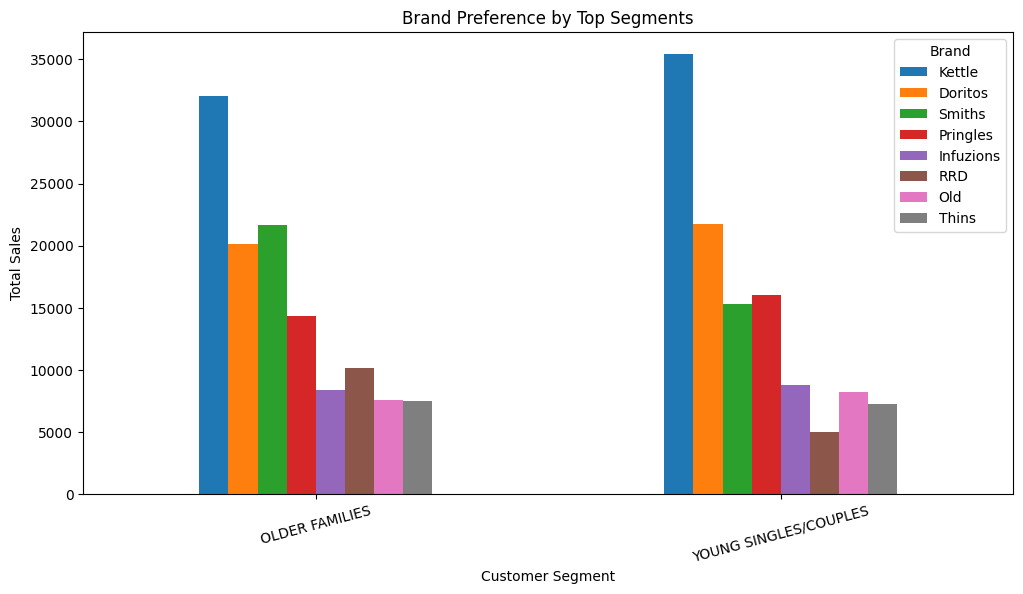

In [158]:
segment_brand_plot = top_segments.groupby(
    ['LIFESTAGE', 'BRAND']
)['TOT_SALES'].sum().unstack().fillna(0)

# Keep only top 8 brands by total sales to keep chart readable
top_brands = merged_data.groupby('BRAND')['TOT_SALES'].sum().nlargest(8).index
segment_brand_plot = segment_brand_plot[top_brands]

segment_brand_plot.plot(kind='bar', figsize=(12, 6))

plt.title('Brand Preference by Top Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=15)
plt.legend(title='Brand', bbox_to_anchor=(1, 1))

plt.savefig('brand_preference_by_segment.png', bbox_inches='tight')
plt.show()

Kettle dominates sales in both segments but Young Singles/Couples over-index on it, consistent with their higher spend per unit. Older Families spread spend more evenly across Smiths and Doritos compared with some other brands. Push Kettle to younger shoppers, multi-buy Smiths/Doritos deals to families.

In [159]:
merged_data['MULTIPACK'] = merged_data['PROD_QTY'] > 1

In [160]:
multipack_segment = merged_data.groupby(
    ['LIFESTAGE', 'PREMIUM_CUSTOMER']
)['MULTIPACK'].mean().sort_values(ascending=False)

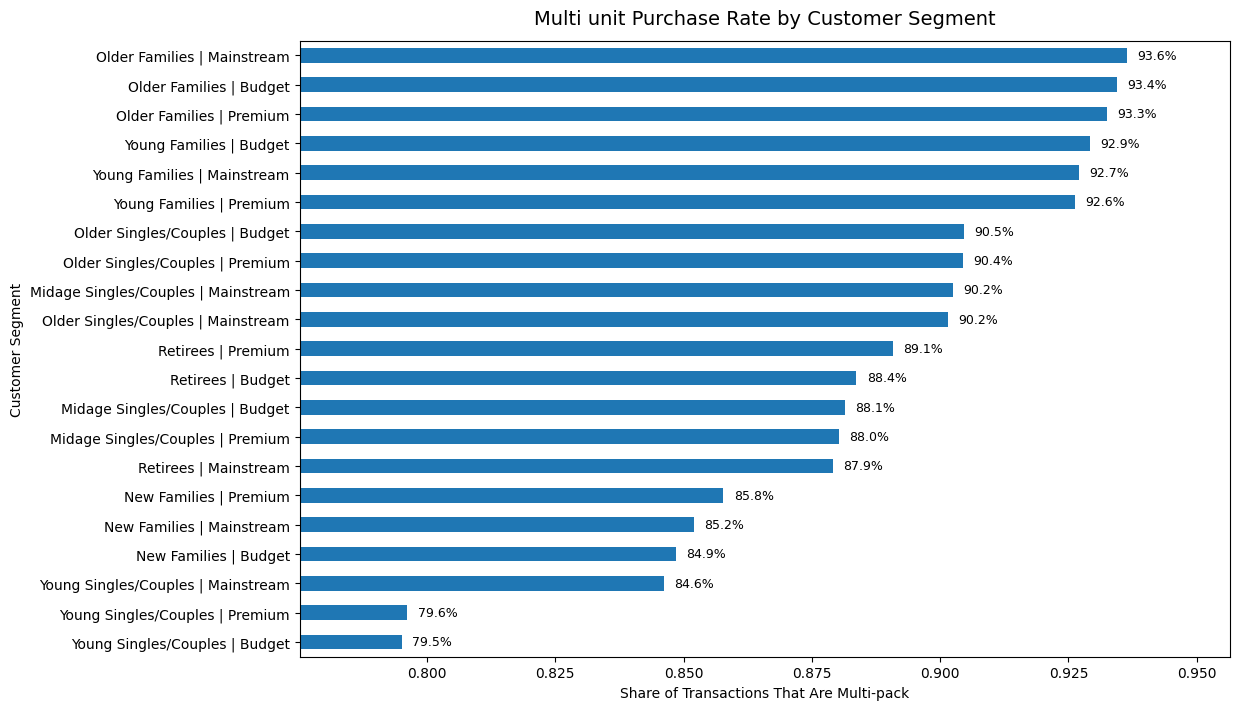

In [161]:
# Convert MultiIndex or tuple index into readable labels
multipack_segment_plot = multipack_segment.copy()
multipack_segment_plot.index = [
    f"{life.title()} | {premium.title()}"
    for life, premium in multipack_segment_plot.index
]

# Sort values
multipack_segment_plot = multipack_segment_plot.sort_values()

plt.figure(figsize=(12, 8))

ax = multipack_segment_plot.plot(kind="barh")

plt.title("Multi unit Purchase Rate by Customer Segment", fontsize=14, pad=12)
plt.xlabel("Share of Transactions That Are Multi-pack")
plt.ylabel("Customer Segment")

# Zoom into useful range
plt.xlim(
    multipack_segment_plot.min() - 0.02,
    multipack_segment_plot.max() + 0.02
)

# Add value labels
for i, v in enumerate(multipack_segment_plot):
    ax.text(v + 0.002, i, f"{v:.1%}", va="center", fontsize=9)

plt.savefig("multipack_rate.png", dpi=300, bbox_inches="tight")
plt.show()

Most customer segments frequently purchased multiple chip packs per transaction. Older Families showed the highest multi-pack purchasing behaviour, supporting their strong contribution to overall sales.

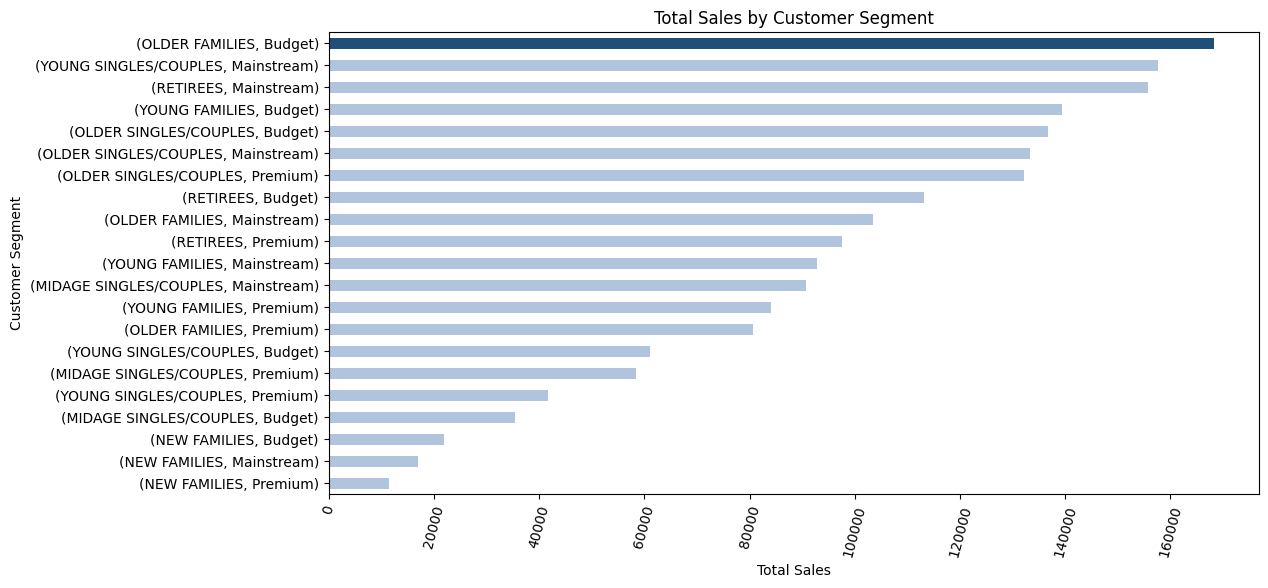

In [162]:
segment_sales_plot = merged_data.groupby(
    ['LIFESTAGE', 'PREMIUM_CUSTOMER']
)['TOT_SALES'].sum().sort_values(ascending=False)

colors = ['#1f4e79'] + ['#b0c4de'] * (len(segment_sales_plot) - 1)
plt.figure(figsize=(12,6))

ax=segment_sales_plot.plot(kind='barh',color=colors)

#put highest at top
ax.invert_yaxis()

plt.title('Total Sales by Customer Segment')
plt.ylabel('Customer Segment')
plt.xlabel('Total Sales')

plt.xticks(rotation=75)

plt.savefig('sales_by_segment.png', bbox_inches='tight')
plt.show()


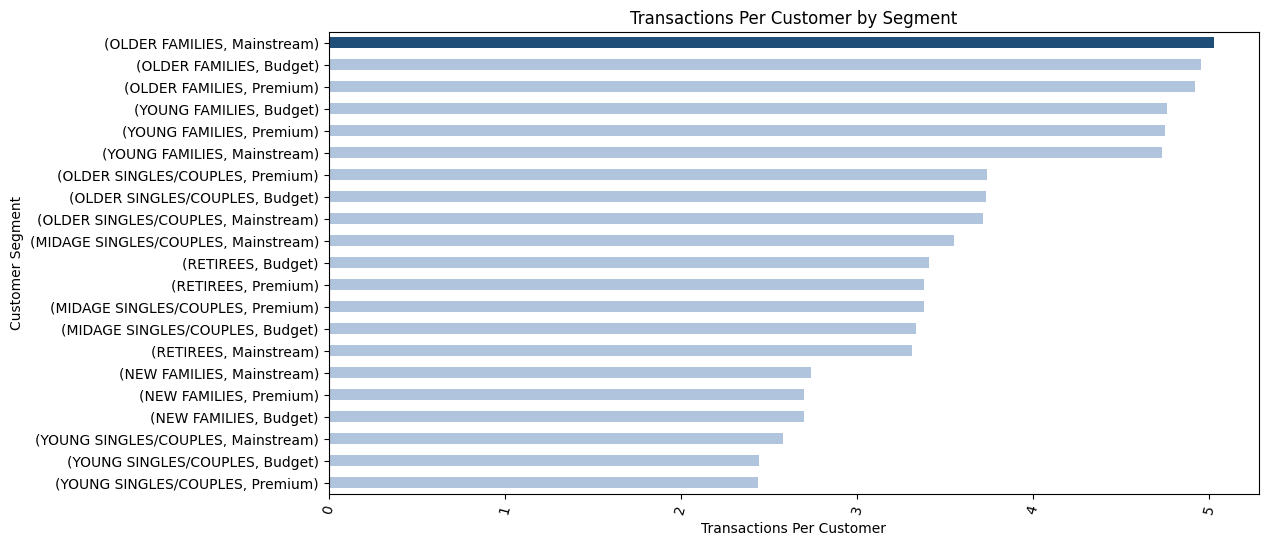

In [163]:
txn_plot = segment_metrics['TXN_PER_CUSTOMER'].sort_values(ascending=False)

colors = ['#1f4e79'] + ['#b0c4de'] * (len(segment_sales_plot) - 1)
plt.figure(figsize=(12,6))

tx=txn_plot.plot(kind='barh',color=colors)
tx.invert_yaxis()

plt.title('Transactions Per Customer by Segment')
plt.xlabel('Transactions Per Customer')
plt.ylabel('Customer Segment')

plt.xticks(rotation=75)
plt.tight_layout
plt.savefig('transactions_per_customer.png', bbox_inches='tight')
plt.show()

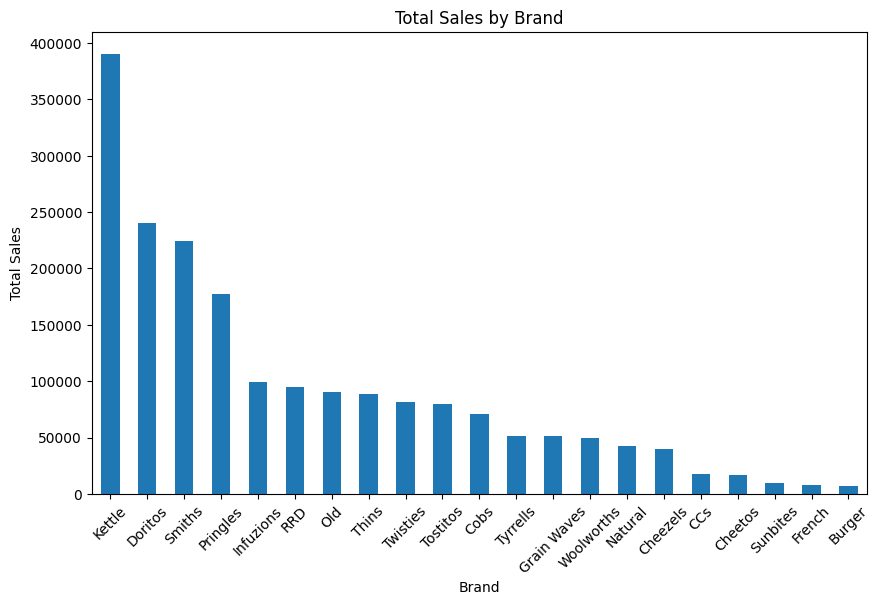

In [164]:
brand_plot = merged_data.groupby(
    'BRAND'
)['TOT_SALES'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))

brand_plot.plot(kind='bar')

plt.title('Total Sales by Brand')
plt.ylabel('Total Sales')
plt.xlabel('Brand')

plt.xticks(rotation=45)

plt.savefig('brand_sales.png', bbox_inches='tight')
plt.show()


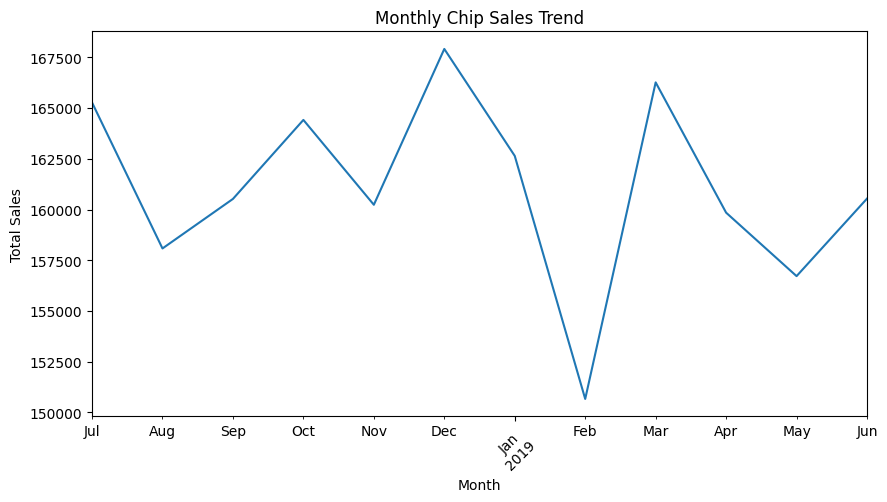

In [165]:
monthly_sales = merged_data.groupby(
    merged_data['DATE'].dt.to_period('M')
)['TOT_SALES'].sum()

monthly_sales.plot(figsize=(10,5))

plt.title('Monthly Chip Sales Trend')
plt.ylabel('Total Sales')
plt.xlabel('Month')

plt.xticks(rotation=45)

plt.savefig('monthly_sales_trend.png', bbox_inches='tight')
plt.show()

Chip sales remained relatively stable throughout the year, with a noticeable peak in December and a decline in February.

The December increase may reflect seasonal holiday purchasing behaviour and higher summer demand in Australia, the January–February trough likely reflects post-holiday spending normalisation combined with back-to-school budget pressure.

These seasonal patterns may help inform promotional planning and inventory management for future category strategies.

In [166]:
merged_data.to_csv('merged_data.csv', index=False)
segment_metrics.to_csv('segment_metrics.csv')

# Key Findings and Recommendations

## Key Findings

- **Older Families (Budget)** generated the highest total chip sales and showed the highest purchase frequency (~5 transactions per customer), with the largest basket sizes — driven by strong multi-pack purchasing behaviour.
- **Mainstream Young Singles/Couples** represent the largest customer group by volume and pay the highest average price per unit, indicating a preference for premium products over value deals.
- **Multi-pack purchasing** is common across all segments but peaks in family segments, particularly Older Families, supporting their outsized contribution to total sales.
- **Kettle dominates** overall brand sales and is especially strong among Mainstream Young Singles/Couples. Budget Older Families distribute spend more evenly across Smiths and Doritos.
- **Seasonal trends** show a clear December sales peak driven by holiday and summer demand in Australia, with a notable February dip representing post-holiday normalisation.
- **Pack size preference** is consistent across all segments (~180g average), indicating pack size is not a meaningful differentiator between customer groups.

## Recommendations

- Target family segments through value-focused promotions, larger pack sizes and multi-buy offers, as these customers contribute strongly through purchase frequency and basket size.
- Continue engaging Mainstream Young Singles/Couples using premium products, convenience-based offerings and new flavour innovations, as this segment shows higher willingness to spend per unit.
- Maintain strong visibility and promotional support for leading brands such as Kettle, Doritos and Smiths, as they are major contributors to overall category sales.

## Conclusion

The analysis identified clear differences in purchasing behaviour across customer segments. Family households contribute strongly through frequent and higher-volume purchases, while younger mainstream customers contribute through higher-value purchasing behaviour. These insights can support more targeted promotional and category strategies for the upcoming chip category review.